Name : Nisha Yuvraj Pragane | DIV:SEDA | Roll no :13 | PRN : 1252090013 | BATCH :B1
10. Assignment on Regression technique.

Download temperature data from the link below.

https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

Apply Linear Regression using a suitable library function and predict the Month-wise temperature.
Assess the performance of regression models using MSE, MAE and R-Square   
metrics
Visualize a simple regression model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Load dataset

In [ ]:
data = pd.read_csv("temperatures.csv")

In [ ]:
print(data.head())

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  


Convert Month names into numbers

In [ ]:
months = ['JAN','FEB','MAR','APR','MAY','JUN',
          'JUL','AUG','SEP','OCT','NOV','DEC']

df = data.melt(id_vars=['YEAR'],
               value_vars=months,
               var_name='Month',
               value_name='Temperature')
month_map = {
    'JAN':1,'FEB':2,'MAR':3,'APR':4,
    'MAY':5,'JUN':6,'JUL':7,'AUG':8,
    'SEP':9,'OCT':10,'NOV':11,'DEC':12
}

df['Month_Num'] = df['Month'].map(month_map)

print(df.head())

   YEAR Month  Temperature  Month_Num
0  1901   JAN        22.40          1
1  1902   JAN        24.93          1
2  1903   JAN        23.44          1
3  1904   JAN        22.50          1
4  1905   JAN        22.00          1


In [ ]:
X = df[['Month_Num']]
y = df['Temperature']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Apply Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 9.999806682283973
MAE: 2.705271869781447
R2 Score: -0.005573628993982727


Visualization

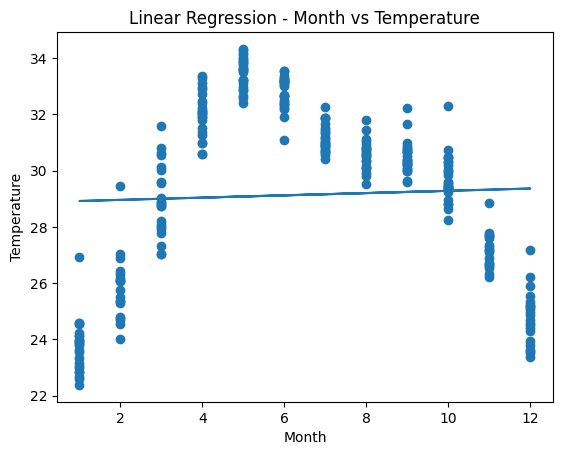

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Linear Regression - Month vs Temperature")
plt.show()